# Japan — F-Score grid study: basket k = 30, random draws = 2000

One cell of the reviewer-suggested 3 x 3 x 2 grid (basket sizes 20/25/30 x
random-sample sizes 1,000/2,000/5,000 x two markets). Signals come from the
team-computed workbook (`data/processed/`, exact Piotroski conventions,
financial firms removed); prices from the cached Yahoo data. Formations are
July 1 of **2012-2025** (14 chained holding years) using score year T-1 —
one conservative timing rule for both markets, over identical calendar time
so the two are comparable. The evaluation window ends 2025-12-31.
Covariances are estimated on 36 months of daily returns ending the day
before formation. Note the panel resolves to *currently listed* symbols, so
the universe is survivorship-tilted — disclosed as a data limitation. The value control falls back to the universe
in years before B/M coverage begins (flagged in the diagnostics).

Peer-review design points (see `src/fscore/grid.py` docstring): explicit
random basis = full eligible universe with fresh draws each year and reported
overlap; a non-F-Score random control; strict F ≥ 8 portfolio; universe EW
and plain universe minimum-variance controls; a dollar-neutral long-short
book (long top-k scores, short bottom-k, charged both legs' trading costs
plus a stock-borrow fee) wherever shorting is available — Vietnam runs
long-only, so `fscore_LS` is simply absent there; denoised
(not detoned) GMV;
primary measure fixed in advance = net-of-cost Sharpe (20 bp per side,
rf = 0); and the synergy test D = Sharpe(GMV) − Sharpe(EW) computed per
basket. All figures are saved at dpi = 300.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.data.team_scores import (load_team_scores, sectors_from_scores,
                                     exclusion_report)
from fscore.grid import run_grid
from fscore.plotting import setup_plots, save_fig

setup_plots()          # study-wide figure defaults; every saved chart is 300 dpi
MARKET, K, N_MC = "japan", 30, 2000
YEARS = list(range(2012, 2026))
FIG = ROOT / "results" / "figures"
OUT = ROOT / "results" / "grid"; OUT.mkdir(parents=True, exist_ok=True)
TAG = "japan_k30_mc2000"

scores = load_team_scores(MARKET, ROOT / "data")
prices = pd.read_csv(ROOT / "data" / f"{MARKET}_prices.csv.gz", parse_dates=["date"])
sectors = sectors_from_scores(scores)
study = run_grid(MARKET, scores, prices, sectors, YEARS, k=K, n_mc=N_MC,
                 n_gmv=300, seed=42)
diag = study.diagnostics()
diag.round(3)

,universe,dropped_no_price,bm_coverage,k,value_fallback,value_basket_size,n_fscore_high,fscore_mean,fscore_basket_min,tie_break_slots,overlap_random_vs_fscore,overlap_expected,cov_est_days,cov_min_est_days,delisted_in_holding_year,no_price_after_formation,long_short_run,short_leg_max_fscore
year,,,,,,,,,,,,,,,,,,
2012,78,3,0,30,True,78,22,6.769,7.0,8,0.387,0.385,733,366,0,0,True,7.0
2013,70,2,0,30,True,70,6,5.629,6.0,11,0.429,0.429,734,367,0,0,True,5.0
2014,72,2,0,30,True,72,12,5.972,7.0,18,0.417,0.417,736,368,0,0,True,5.0
2015,79,2,0,30,True,79,14,6.430,7.0,16,0.379,0.380,735,367,0,0,True,6.0
2016,77,2,0,30,True,77,15,6.260,7.0,15,0.393,0.390,734,367,0,0,True,6.0
2017,79,2,0,30,True,79,10,5.949,6.0,2,0.378,0.380,735,367,0,0,True,5.0
2018,82,1,0,30,True,82,18,6.476,7.0,12,0.367,0.366,750,375,0,0,True,6.0
2019,81,1,0,30,True,81,15,6.395,7.0,15,0.375,0.370,753,376,0,0,True,6.0
2020,79,0,0,30,True,79,4,5.684,6.0,10,0.378,0.380,751,375,0,0,True,5.0


### 0. Data discarded before any test

A firm-year enters the study only with a **complete nine-signal F-Score**.
Partial scores are dropped rather than summed over whatever is available —
an incomplete score is not a low score, and keeping them would push those
firms towards the bottom of the ranking and into the short leg. The table
below is the full accounting; `dropped_no_price` in the diagnostics above
counts the further names removed for insufficient price history.

In [2]:
drops_total = exclusion_report(MARKET, ROOT / "data")
drops_year = exclusion_report(MARKET, ROOT / "data", by_year=True)
drops_total.to_csv(OUT / f"{TAG}_exclusions.csv")
print(f"{MARKET.upper()}: {int(drops_total.dropped_incomplete_signals.iloc[0])} of "
      f"{int(drops_total.rows.iloc[0])} firm-years dropped for incomplete signals "
      f"({drops_total.pct_dropped_incomplete.iloc[0]:.1f}%); "
      f"{drops_total.pct_kept.iloc[0]:.1f}% kept")
drops_total

JAPAN: 187 of 1974 firm-years dropped for incomplete signals (9.5%); 90.1% kept


,rows,dropped_incomplete_signals,dropped_no_symbol,dropped_no_score,kept,pct_dropped_incomplete,pct_kept
japan,1974.0,187.0,8.0,0.0,1779.0,9.47,90.12


### 1. Summary (primary measure: net-of-cost Sharpe; rf = 0)

Costs are 20 bp per side charged on each strategy's **own** one-way turnover,
computed from its actual weights — so the optimised portfolios pay for weight
drift and the near-static universe control pays almost nothing. The
long-short book (`fscore_LS`, present only where shorting is available) pays
both legs plus a 100 bp annual stock-borrow fee on its short notional.

In [3]:
summary = study.summary()
summary[["ann_return", "ann_vol", "sharpe", "max_drawdown",
         "turnover", "cost_drag", "net_ann_return", "net_sharpe"]].round(3)

,ann_return,ann_vol,sharpe,max_drawdown,turnover,cost_drag,net_ann_return,net_sharpe
fscore_EW,0.165,0.198,0.836,-0.326,0.577,0.002,0.163,0.825
fscore_GMV,0.133,0.175,0.758,-0.396,0.776,0.003,0.129,0.740
fscore_GMVsec,0.152,0.176,0.863,-0.350,0.820,0.003,0.148,0.844
fscore_high_EW,0.170,0.206,0.824,-0.335,0.827,0.003,0.166,0.808
value_EW,0.166,0.199,0.834,-0.317,0.214,0.001,0.165,0.830
universe_EW,0.154,0.192,0.802,-0.317,0.050,0.000,0.154,0.801
universe_GMV,0.130,0.163,0.796,-0.412,0.348,0.001,0.128,0.787
fscore_LS,0.019,0.071,0.269,-0.121,1.182,0.015,0.004,0.061


### 2. Yearly returns (July–June holding years; final year ends Dec 2025)

In [4]:
yearly = study.yearly_returns()
(yearly * 100).round(1)

,fscore_EW,fscore_GMV,fscore_GMVsec,fscore_high_EW,value_EW,universe_EW,universe_GMV,fscore_LS
date,,,,,,,,
2012,14.8,3.4,8.5,14.1,13.4,13.4,5.4,3.4
2013,54.4,58.4,68.5,44.3,53.3,53.3,41.6,2.7
2014,15.0,24.6,17.2,13.7,12.6,12.6,19.3,6.3
2015,12.4,25.1,26.0,12.8,13.3,13.3,33.8,-4.0
2016,7.4,1.7,3.4,11.9,4.8,4.8,1.9,2.6
2017,19.8,38.5,24.4,14.8,24.9,24.9,37.5,-6.6
2018,-4.7,-22.5,-19.3,-1.1,-11.3,-11.3,-18.8,16.2
2019,14.6,6.5,10.1,18.3,14.5,14.5,1.9,3.0
2020,3.4,-7.1,-0.1,1.5,5.3,5.3,-12.3,-2.9


### 3. Placement vs the random distributions

Reported gross and net of costs. The random control is redrawn every year, so
it carries its own turnover (~1 − k/|universe|) — charging both sides is the
like-for-like comparison; the gross rows show costs are not driving it.

Significance is judged at **one level fixed in advance: 5%** (`significant`
column = p < 0.05). There is no 1% or 10% tier: p = 0.06 is not
significant.

In [5]:
rows = {}
for pool, label in [("mc_ew", "random (full universe)"),
                    ("mc_nonf_ew", "random (non-F-Score names)")]:
    frame = getattr(study, pool)
    if frame.shape[1]:
        for stat in ["sharpe", "ann_return"]:
            for net in (False, True):
                basis = "net" if net else "gross"
                rows[(label, stat, basis)] = study.placement(
                    "fscore_EW", pool, stat, net=net)
placement = pd.DataFrame(rows).T
print(f"turnover — F-Score EW {study.strategy_turnover('fscore_EW'):.3f} "
      f"vs random basket {study.mc_turnover():.3f} (one-way, per year)")
placement.round(3)

turnover — F-Score EW 0.577 vs random basket 0.627 (one-way, per year)


percentile p_value significant  \
random (full universe)     sharpe     gross     0.8275  0.1725       False   
                                      net        0.832   0.168       False   
                           ann_return gross      0.874   0.126       False   
                                      net       0.8775  0.1225       False   
random (non-F-Score names) sharpe     gross      0.984   0.016        True   
                                      net       0.9855  0.0145        True   
                           ann_return gross     0.9935  0.0065        True   
                                      net        0.995   0.005        True   

                                            alpha n_draws random_mean  \
random (full universe)     sharpe     gross  0.05    2000    0.788172   
                                      net    0.05    2000    0.775351   
                           ann_return gross  0.05    2000    0.154153   
                                      net    0.05    2000    0.151646   
random (non-F-Score names) sharpe     gross  0.05    2000    0.750165   
                                      net    0.05    2000    0.737283   
                           ann_return gross  0.05    2000    0.146024   
                                      net    0.05    2000    0.143517   

                                            random_std    fscore  basis  
random (full universe)     sharpe     gross   0.051999  0.836167  gross  
                                      net     0.051975  0.824505    net  
                           ann_return gross   0.010019  0.165458  gross  
                                      net     0.010019   0.16315    net  
random (non-F-Score names) sharpe     gross   0.040602  0.836167  gross  
                                      net     0.040583  0.824505    net  
                           ann_return gross   0.007785  0.165458  gross  
                                      net     0.007785   0.16315    net

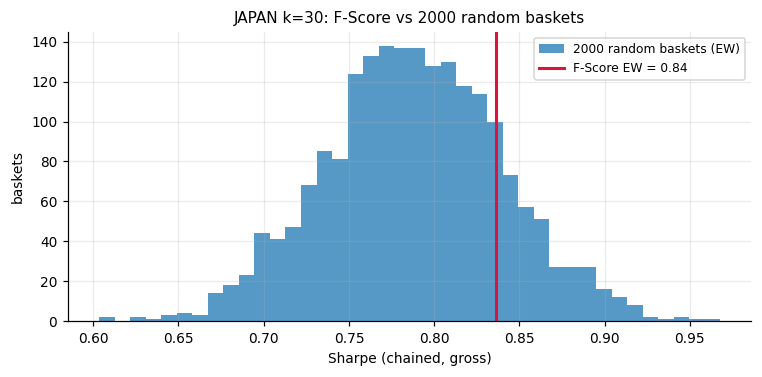

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sh = study.mc_metric(study.mc_ew, "sharpe")
ax.hist(sh, bins=40, alpha=0.75, label=f"{N_MC} random baskets (EW)")
# the placement index is (pool, statistic, basis); the histogram shows gross
fs = placement.loc[("random (full universe)", "sharpe", "gross"), "fscore"]
ax.axvline(fs, color="crimson", lw=2, label=f"F-Score EW = {fs:.2f}")
ax.set_xlabel("Sharpe (chained, gross)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
ax.set_title(f"{MARKET.upper()} k={K}: F-Score vs {N_MC} random baskets")
plt.tight_layout()
save_fig(f"{TAG}_mc_hist", directory=FIG)
plt.show()

### 4. Synergy test: per-basket optimisation gain
D = Sharpe(GMV) − Sharpe(EW), judged at the 5% level.

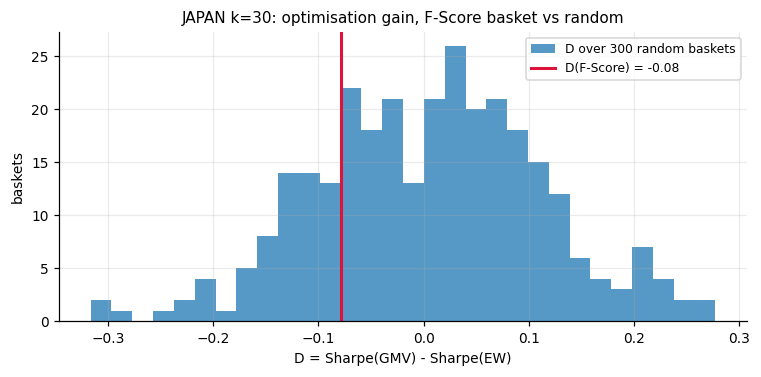

percentile       0.217
p_value          0.783
significant          0
alpha             0.05
n_draws            300
random_mean      0.005
random_std       0.107
D_fscore        -0.078
D_random_mean    0.005
D_random_std     0.107
n                  300
dtype: object

In [7]:
syn = study.synergy()
d_rand = (study.mc_metric(study.mc_gmv, "sharpe")
          - study.mc_metric(study.mc_ew[list(range(study.mc_gmv.shape[1]))], "sharpe")).dropna()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(d_rand, bins=30, alpha=0.75, label=f"D over {len(d_rand)} random baskets")
ax.axvline(syn["D_fscore"], color="crimson", lw=2,
           label=f"D(F-Score) = {syn['D_fscore']:.2f}")
ax.set_xlabel("D = Sharpe(GMV) - Sharpe(EW)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
ax.set_title(f"{MARKET.upper()} k={K}: optimisation gain, F-Score basket vs random")
plt.tight_layout()
save_fig(f"{TAG}_synergy_hist", directory=FIG)
plt.show()
pd.Series(syn).round(3)

### 5. Track record and outputs

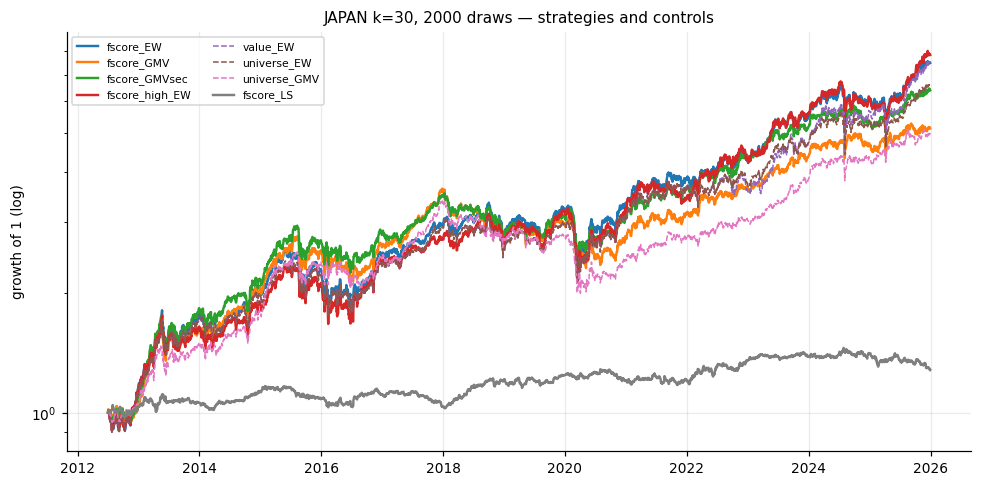

saved japan_k30_mc2000


In [8]:
nav = (1 + study.daily.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.5))
for c in nav.columns:
    ax.plot(nav.index, nav[c], lw=1.6 if c.startswith("fscore") else 1.0,
            ls="-" if c.startswith("fscore") else "--", label=c)
ax.set_yscale("log"); ax.set_ylabel("growth of 1 (log)"); ax.legend(fontsize=7, ncol=2)
ax.set_title(f"{MARKET.upper()} k={K}, {N_MC} draws — strategies and controls")
plt.tight_layout()
save_fig(f"{TAG}_nav", directory=FIG)
plt.show()

summary.to_csv(OUT / f"{TAG}_summary.csv")
placement.to_csv(OUT / f"{TAG}_placement.csv")
pd.Series(syn).to_frame("value").to_csv(OUT / f"{TAG}_synergy.csv")
yearly.to_csv(OUT / f"{TAG}_yearly_returns.csv")
diag.to_csv(OUT / f"{TAG}_diagnostics.csv")
print("saved", TAG)